In [5]:
# Імпорти
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error

!pip install statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import OLSInfluence

from scipy import stats

# Налаштування відображення
%matplotlib inline
plt.rcParams['figure.figsize'] = (8,5)
sns.set(style="whitegrid")



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\lqd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
DATA_PATH = "student_performance.csv"  

df = pd.read_csv(DATA_PATH)

df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [7]:
# Інформація по колонкам та типах
print("INFO:")
display(df.info())

# Статистичний опис числових змінних
print("\nDESCRIBE:")
display(df.describe(include='all').T)

# Перевірка на пропуски
print("\nПропущені значення по стовпцях:")
display(df.isnull().sum())


INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


None


DESCRIBE:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours Studied,10000.0,NaN,NaN,NaN,4.9929,2.589309,1.0,3.0,5.0,7.0,9.0
Previous Scores,10000.0,NaN,NaN,NaN,69.4457,17.343152,40.0,54.0,69.0,85.0,99.0
Extracurricular Activities,10000,2,No,5052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep Hours,10000.0,NaN,NaN,NaN,6.5306,1.695863,4.0,5.0,7.0,8.0,9.0
Sample Question Papers Practiced,10000.0,NaN,NaN,NaN,4.5833,2.867348,0.0,2.0,5.0,7.0,9.0
Performance Index,10000.0,NaN,NaN,NaN,55.2248,19.212558,10.0,40.0,55.0,71.0,100.0



Пропущені значення по стовпцях:


Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

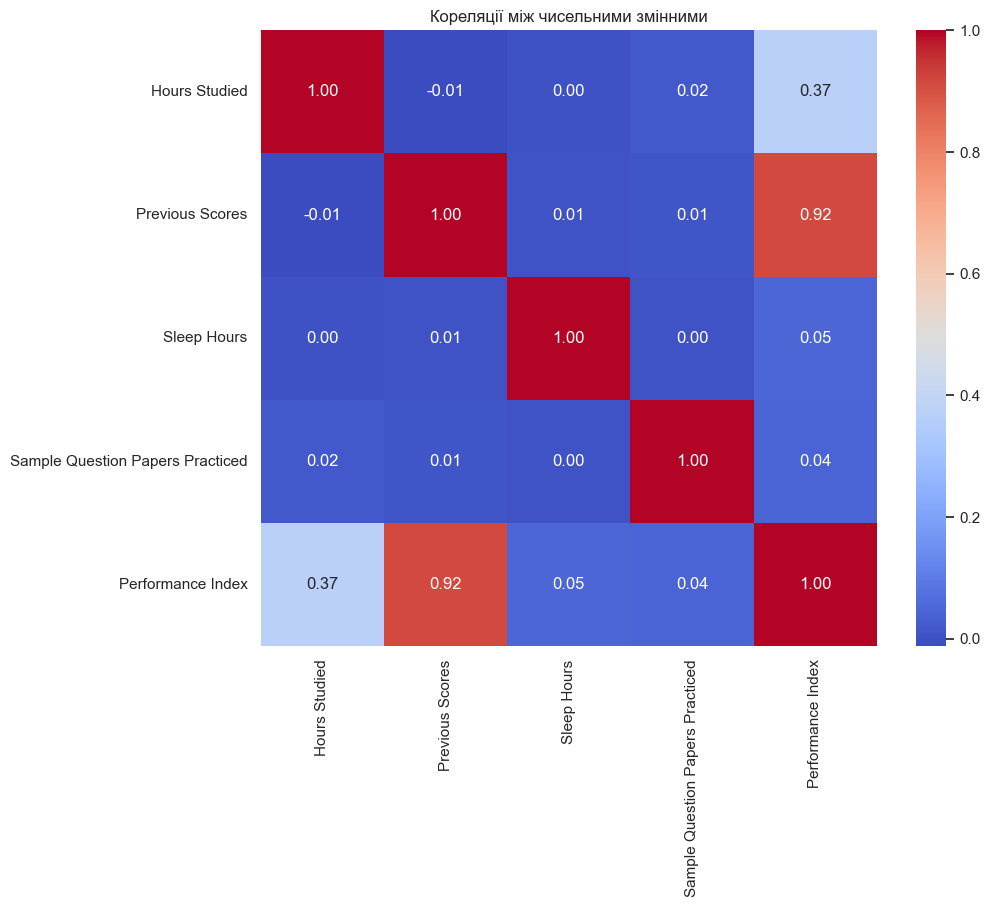

In [8]:
# Побудуємо теплокарту кореляцій для чисельних змінних
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Кореляції між чисельними змінними")
plt.show()


In [ ]:
target_col = None
for c in df.columns:
    if 'performance' in c.lower() or 'performance index' in c.lower() or 'performance_index' in c.lower():
        target_col = c
        break

if target_col is None:
    # Якщо не знайшли, просто виведемо назви колонок для уточнення
    print("Не вдалося автоматично знайти цільову колонку. Ось список колонок:")
    print(df.columns.tolist())
else:
    print(f"Вибрана цільова колонка: {target_col}")
    # Кореляція з чисельними предикторами
    corr_with_target = df[numeric_cols].corr()[target_col].sort_values(ascending=False)
    display(corr_with_target)


Вибрана цільова колонка: Performance Index


Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64

In [ ]:
# Які є нечислові (категоріальні) колонки
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Категоріальні колонки:", cat_cols)

binary_map = {'yes':1, 'no':0, 'Yes':1, 'No':0, 'YES':1, 'NO':0}

df_proc = df.copy()

# Мапимо бінарні
for c in cat_cols:
    unique_vals = df_proc[c].dropna().unique()
    if set(map(lambda x: str(x).lower(), unique_vals)) <= {'yes','no'}:
        df_proc[c] = df_proc[c].map(binary_map)
    else:
        pass

remaining_cat = df_proc.select_dtypes(include=['object', 'category']).columns.tolist()
df_proc = pd.get_dummies(df_proc, columns=remaining_cat, drop_first=True)

print("Розмір після перетворень:", df_proc.shape)


Категоріальні колонки: ['Extracurricular Activities']
Розмір після перетворень: (10000, 6)


In [ ]:
# Переконаємося, що target_col визначений
if target_col is None:
    raise ValueError("Не вказано цільову колонку. Встанови `target_col` вручну перед виконанням.")

X = df_proc.drop(columns=[target_col])
y = df_proc[target_col].values

print("Форма X:", X.shape)
print("Довжина y:", y.shape)


Форма X: (10000, 5)
Довжина y: (10000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (8000, 5) Test shape: (2000, 5)


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Додаємо стовпчик одиниць для β0 (intercept)
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final  = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)


X_train_final shape: (8000, 6)
X_test_final shape: (2000, 6)


In [14]:
def compute_cost(X, y, b):
    """
    Обчислення MSE (середньоквадратичної помилки).
    X: матриця (n_samples, n_features+1), де перший стовпчик — одиниці
    b: вектор ваг (n_features+1,)
    y: вектор цілі (n_samples,)
    """
    m = len(y)
    predictions = X.dot(b)
    errors = predictions - y
    mse = (1 / m) * np.sum(errors ** 2)
    return mse

def gradient_descent(X, y, b_init, learning_rate=0.01, epochs=1000, verbose=False):
    """
    Векторизований градієнтний спуск.
    Повертає остаточні ваги та історію cost.
    """
    m = len(y)
    b = b_init.copy().astype(float)
    cost_history = []
    for i in range(epochs):
        predictions = X.dot(b)
        errors = predictions - y
        # Градієнт MSE по b: (2/m) * X^T (X b - y), але ми використовуємо (1/m) визначення для cost -> gradient factor = 2/m
        gradient = (2 / m) * (X.T.dot(errors))
        b -= learning_rate * gradient
        cost = compute_cost(X, y, b)
        cost_history.append(cost)
        if verbose and (i % (epochs//10 if epochs>=10 else 1) == 0):
            print(f"Ітерація {i}, cost = {cost:.6f}")
    return b, cost_history


In [15]:
# Ініціалізація ваг нулями
b_init = np.zeros(X_train_final.shape[1])

# Гіперпараметри
learning_rate = 0.01
epochs = 3000  # можна змінити

# Навчання
b_final, cost_history = gradient_descent(X_train_final, y_train, b_init, learning_rate=learning_rate, epochs=epochs, verbose=True)

print("Навчання завершено.")
print("Перші 5 cost:", cost_history[:5])
print("Останні 5 cost:", cost_history[-5:])


Ітерація 0, cost = 3292.539047
Ітерація 300, cost = 4.187826
Ітерація 600, cost = 4.169736
Ітерація 900, cost = 4.169736
Ітерація 1200, cost = 4.169736
Ітерація 1500, cost = 4.169736
Ітерація 1800, cost = 4.169736
Ітерація 2100, cost = 4.169736
Ітерація 2400, cost = 4.169736
Ітерація 2700, cost = 4.169736
Навчання завершено.
Перші 5 cost: [3292.5390473201296, 3162.4053983231065, 3037.421830404353, 2917.3845203301853, 2802.0977117953485]
Останні 5 cost: [4.169735849525006, 4.169735849525006, 4.169735849525006, 4.169735849525006, 4.169735849525006]


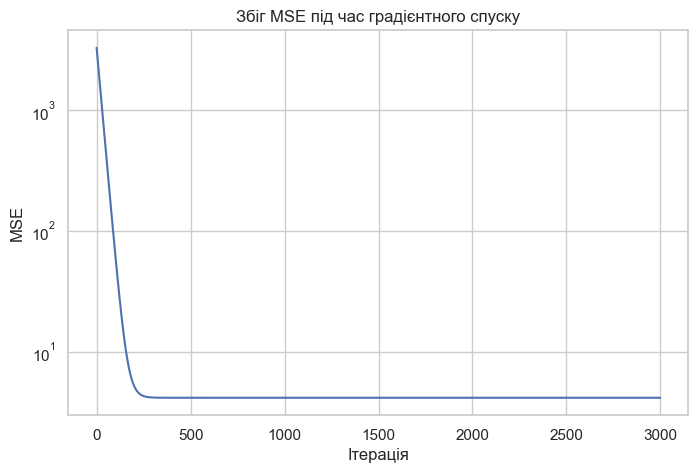

In [16]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Ітерація")
plt.ylabel("MSE")
plt.title("Збіг MSE під час градієнтного спуску")
plt.yscale('log')  # іноді корисно для демонстрації зменшення
plt.grid(True)
plt.show()


In [17]:
# Прогноз
y_pred = X_test_final.dot(b_final)

# MSE
mse_test = mean_squared_error(y_test, y_pred)

# R^2 вручну
r2 = 1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2))

print(f"Тестовий MSE: {mse_test:.6f}")
print(f"Тестовий R^2: {r2:.6f}")

# Порівняння з бейзлайном (завжди прогноз = mean(y_train))
baseline_pred = np.mean(y_train)
baseline_mse = np.mean((y_test - baseline_pred)**2)
print(f"Baseline (mean) MSE: {baseline_mse:.6f}")


Тестовий MSE: 4.082628
Тестовий R^2: 0.988983
Baseline (mean) MSE: 370.773038


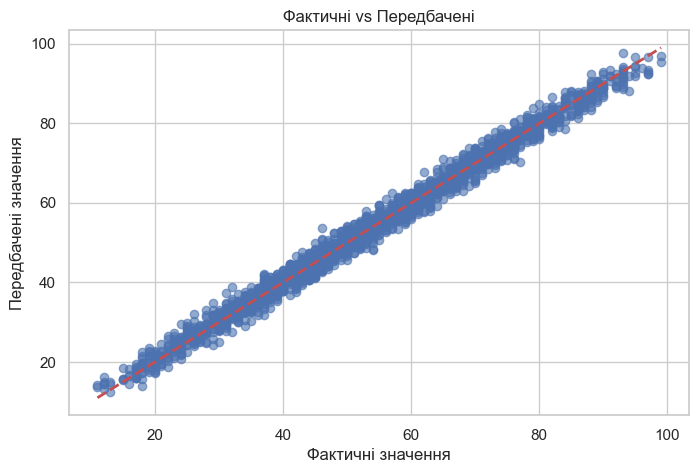

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Фактичні значення")
plt.ylabel("Передбачені значення")
plt.title("Фактичні vs Передбачені")
plt.grid(True)
plt.show()


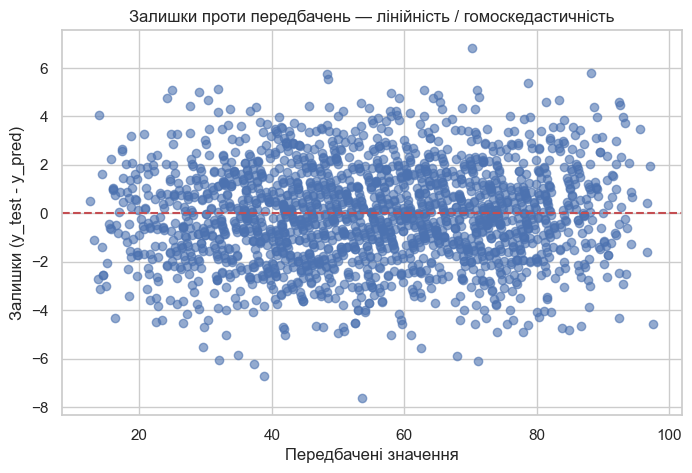

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Передбачені значення")
plt.ylabel("Залишки (y_test - y_pred)")
plt.title("Залишки проти передбачень — лінійність / гомоскедастичність")
plt.grid(True)
plt.show()


In [20]:
# Для VIF потрібно матриця без інтерсепта та з оригінальними назвами колонок після get_dummies
X_for_vif = X.copy()
# Додавання константи не потрібна для VIF обчислення — statsmodels робить це, але ми використовуємо формулу вручну.
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_vals = []
for i in range(X_for_vif.shape[1]):
    vif = variance_inflation_factor(X_for_vif.values, i)
    vif_vals.append(vif)
vif_data["VIF"] = vif_vals

display(vif_data.sort_values(by="VIF", ascending=False).head(20))


,feature,VIF
1,Previous Scores,10.088586
3,Sleep Hours,9.833594
0,Hours Studied,4.263244
4,Sample Question Papers Practiced,3.350481
2,Extracurricular Activities,1.928235


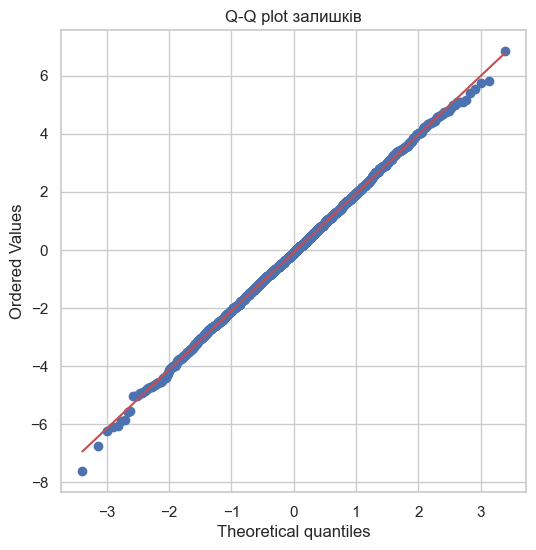

Jarque-Bera stat = 0.0852, p-value = 0.9583
Shapiro-Wilk stat = 0.9996, p-value = 0.9751


In [22]:
# Q-Q plot
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot залишків")
plt.show()

# Jarque-Bera тест
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"Jarque-Bera stat = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}")


# Shapiro-Wilk (зверни увагу, що для великих вибірок Shapiro може повідомляти не нормальність)
try:
    sh_stat, sh_p = stats.shapiro(residuals)
    print(f"Shapiro-Wilk stat = {sh_stat:.4f}, p-value = {sh_p:.4f}")
except Exception as e:
    print("Shapiro-Wilk тест не вдалось виконати (можливо, занадто велика вибірка):", e)


In [ ]:
import statsmodels.stats.api as sms

# Побудуємо OLS модель через statsmodels для тесту Бреуша-Пейгана
model_sm = sm.OLS(y_test, X_test_final).fit()
bp_test = sms.het_breuschpagan(model_sm.resid, model_sm.model.exog)
bp_stat, bp_pvalue = bp_test[0], bp_test[1]

print(f"Breusch-Pagan stat = {bp_stat:.4f}, p-value = {bp_pvalue:.4f}")
print("Якщо p-value < 0.05 — присутня гетероскедастичність (постійна дисперсія під сумнівом).")


Breusch-Pagan stat = 6.6976, p-value = 0.2441
Якщо p-value < 0.05 — присутня гетероскедастичність (постійна дисперсія під сумнівом).


In [24]:
dw_stat = durbin_watson(model_sm.resid)
print(f"Durbin-Watson statistic = {dw_stat:.4f}")
print("Значення близько до 2 → відсутність автокореляції. Близько до 0 → позитивна автокореляція, близько до 4 → негативна.")


Durbin-Watson statistic = 2.0497
Значення близько до 2 → відсутність автокореляції. Близько до 0 → позитивна автокореляція, близько до 4 → негативна.


Порог Cook's D = 2.000000e-03
Кількість впливових спостережень: 108
Індекси впливових спостережень (відносно X_test): [ 11  16  19  36  53  64  98  99 113 163 165 183 185 201 204 206 226 253
 265 267]


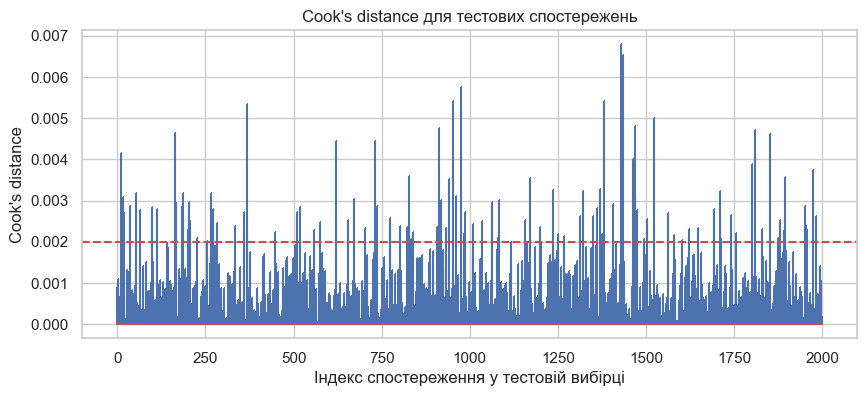

In [ ]:
influence = OLSInfluence(model_sm)
cooks = influence.cooks_distance[0]

# Поріг: 4/n
n = len(y_test)
threshold = 4 / n
influential_points = np.where(cooks > threshold)[0]

print(f"Порог Cook's D = {threshold:.6e}")
print(f"Кількість впливових спостережень: {len(influential_points)}")
if len(influential_points) > 0:
    print("Індекси впливових спостережень (відносно X_test):", influential_points[:20])

# Графік Cook's distance
plt.figure(figsize=(10,4))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",")  # <- fixed line
plt.axhline(threshold, color='r', linestyle='--')
plt.xlabel("Індекс спостереження у тестовій вибірці")
plt.ylabel("Cook's distance")
plt.title("Cook's distance для тестових спостережень")
plt.show()


In [ ]:
# Підготуємо таблицю коефіцієнтів
feature_names = ["Intercept"] + list(X.columns)
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": b_final
})
display(coef_df)

print("\nMSE (test):", mse_test)
print("R^2 (test):", r2)
print("Baseline MSE (mean):", baseline_mse)


,feature,coefficient
0,Intercept,55.311500
1,Hours Studied,7.401341
2,Previous Scores,17.637271
3,Extracurricular Activities,0.304291
4,Sleep Hours,0.810031
5,Sample Question Papers Practiced,0.548842



MSE (test): 4.082628398521849
R^2 (test): 0.9889832909573145
Baseline MSE (mean): 370.77303824999996
